In [6]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
sys.path.insert(0, str(Path('.')))

from cohort_retention.cohort import build_cohort_matrix

In [7]:
# Constants and config
DATA_DIR = Path('..') / 'data' / 'synthetic'
LOOKBACK_DAYS = 90
COHORT_PERIOD = 'W'   # 'W' = weekly, 'M' = monthly
MAX_PERIODS = 16

In [8]:
# Load data
events = pd.read_csv(DATA_DIR / 'events.csv', parse_dates=['occurred_at'])
print(f"{len(events):,} events  |  {events['user_id'].nunique():,} unique users")

51,910 events  |  5,000 unique users


In [9]:
# Build cohort retention matrix
matrix = build_cohort_matrix(
    events,
    period=COHORT_PERIOD,
    max_periods=MAX_PERIODS,
)
print(f"Matrix: {matrix.shape[0]} cohorts × {matrix.shape[1]} periods")
matrix.head()

Matrix: 53 cohorts × 16 periods


periods_since_first_activity,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
cohort_period,,,,,,,,,,,,,,,,
2024-01-01/2024-01-07,1.0,0.085714,0.057143,NaN,0.114286,0.028571,0.028571,0.057143,0.085714,NaN,0.114286,0.028571,0.085714,0.085714,0.085714,0.057143
2024-01-08/2024-01-14,1.0,0.040816,0.061224,0.081633,0.081633,0.081633,0.163265,0.081633,0.081633,0.102041,0.040816,0.081633,0.040816,0.081633,0.102041,0.020408
2024-01-15/2024-01-21,1.0,0.156863,0.117647,0.176471,0.098039,0.058824,0.117647,0.117647,0.137255,0.078431,0.078431,0.098039,0.117647,0.078431,0.156863,0.039216
2024-01-22/2024-01-28,1.0,0.102564,0.051282,0.076923,0.025641,0.102564,0.076923,0.076923,0.230769,0.128205,0.102564,0.076923,0.153846,0.102564,0.153846,0.076923
2024-01-29/2024-02-04,1.0,0.173077,0.057692,0.153846,0.057692,0.076923,0.096154,0.057692,0.076923,0.096154,0.038462,0.076923,0.057692,0.115385,0.057692,0.057692


Task was destroyed but it is pending!
task: <Task pending name='Task-145' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/Viola/Documents/Code/data-bedrock/.venv/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-146' coro=<Kernel.shell_main() running at /Users/Viola/Documents/Code/data-bedrock/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/Viola/Documents/Code/data-bedrock/.venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/Viola/Documents/Code/data-bedrock/.venv/lib/python3.14/site-packages/matplotlib/_api/__init__.py:140: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  if not exists:
Task was destroyed but it is pending!
task: <Task pending name='Task-146' coro=<Kernel.shell_main() running at /Users/Viola/Documents/Code/data-bedrock/.venv/lib/python3.14/site-packages/ipykernel/kerne

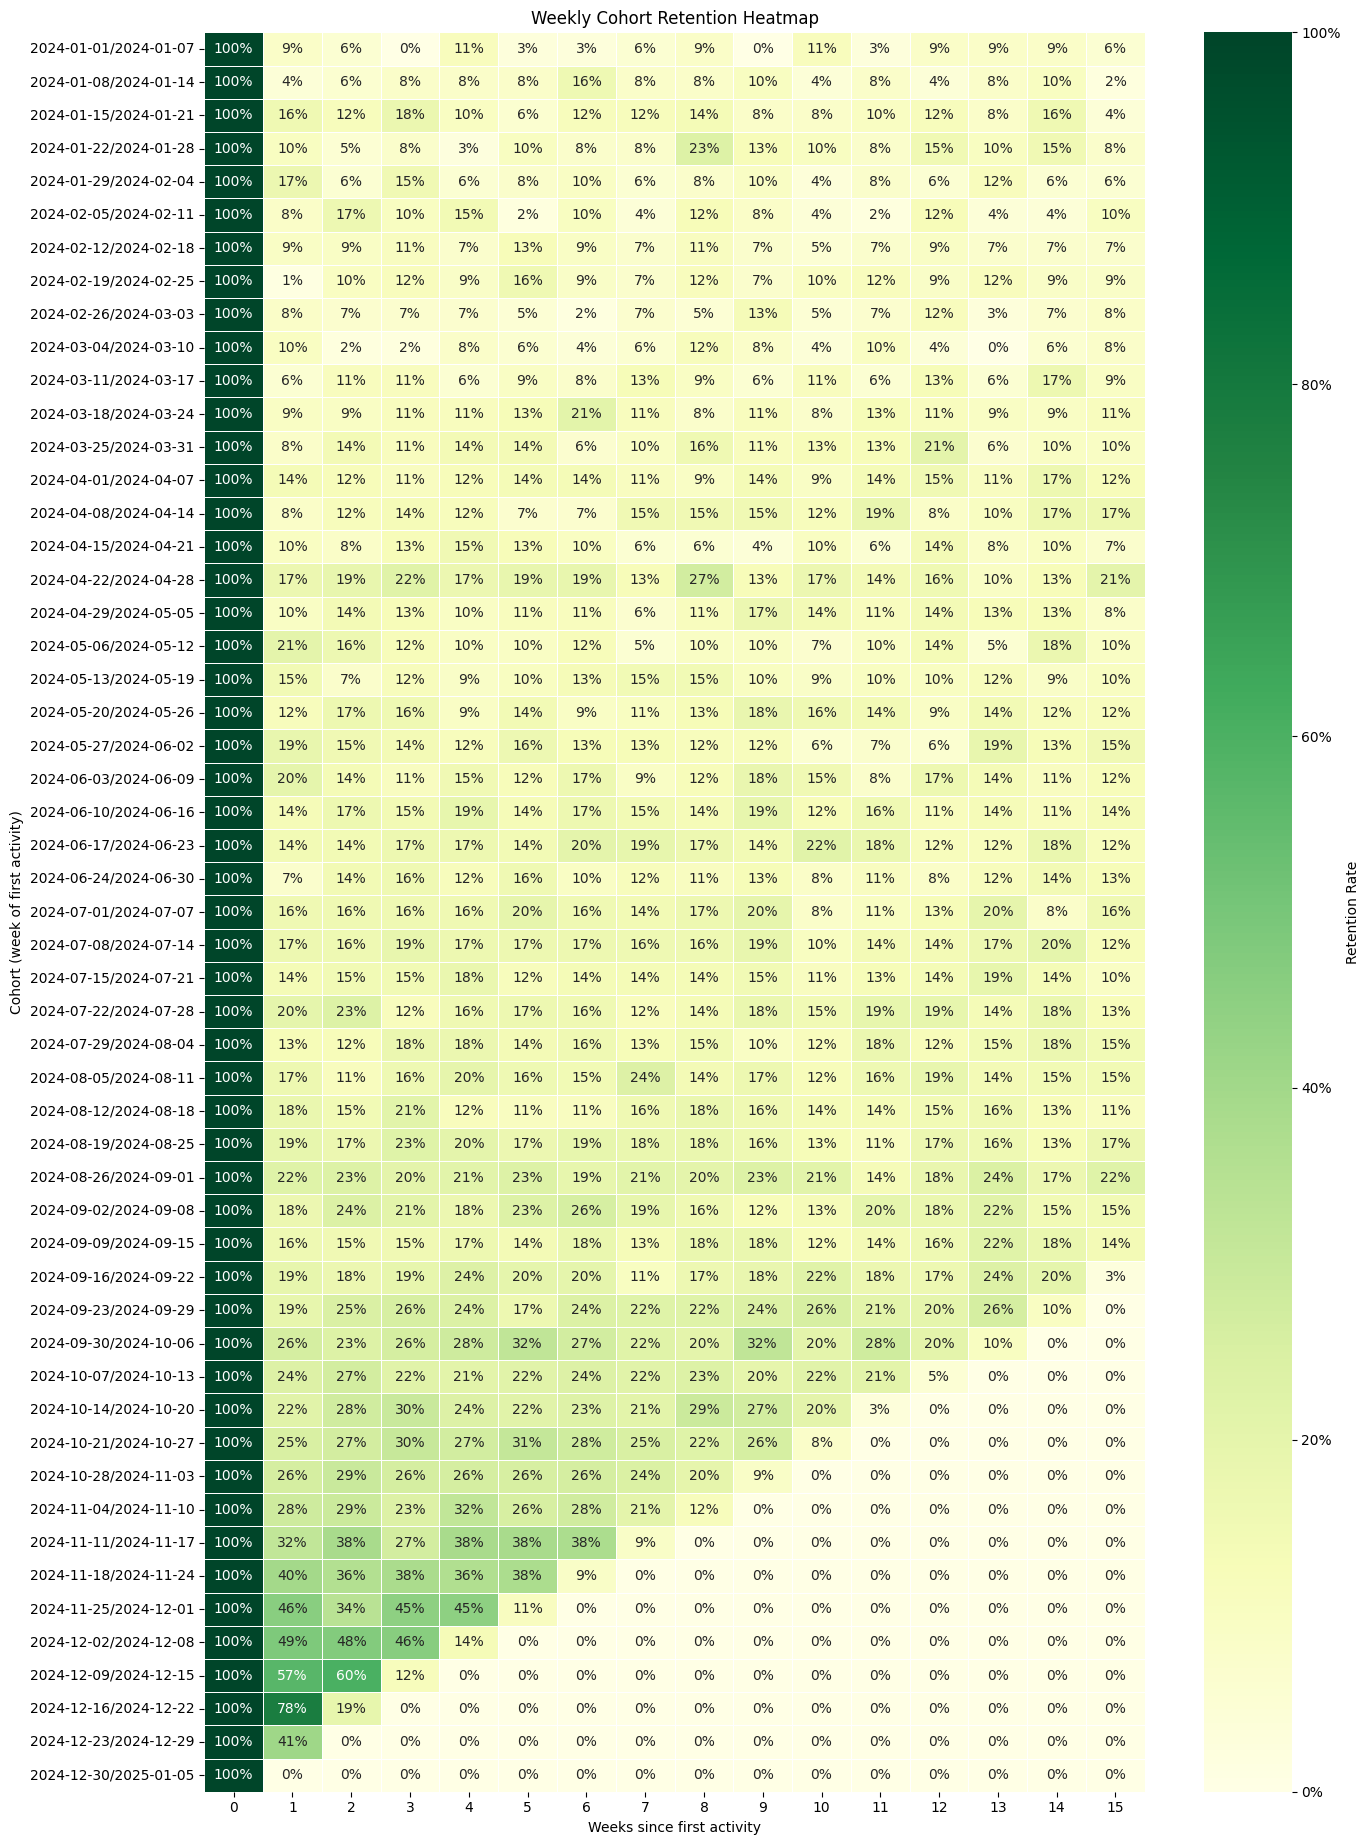

In [10]:
# Plot retention heatmap
fig, ax = plt.subplots(figsize=(14, max(6, len(matrix) * 0.35)))

# Drop periods with no data (trailing NaN columns)
plot_data = matrix.dropna(axis=1, how='all').fillna(0)

sns.heatmap(
    plot_data,
    ax=ax,
    cmap='YlGn',
    vmin=0, vmax=1,
    annot=True,
    fmt='.0%',
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate', 'format': mticker.PercentFormatter(xmax=1)},
)

ax.set_xlabel('Weeks since first activity')
ax.set_ylabel('Cohort (week of first activity)')
ax.set_title('Weekly Cohort Retention Heatmap')
plt.tight_layout()
plt.show()

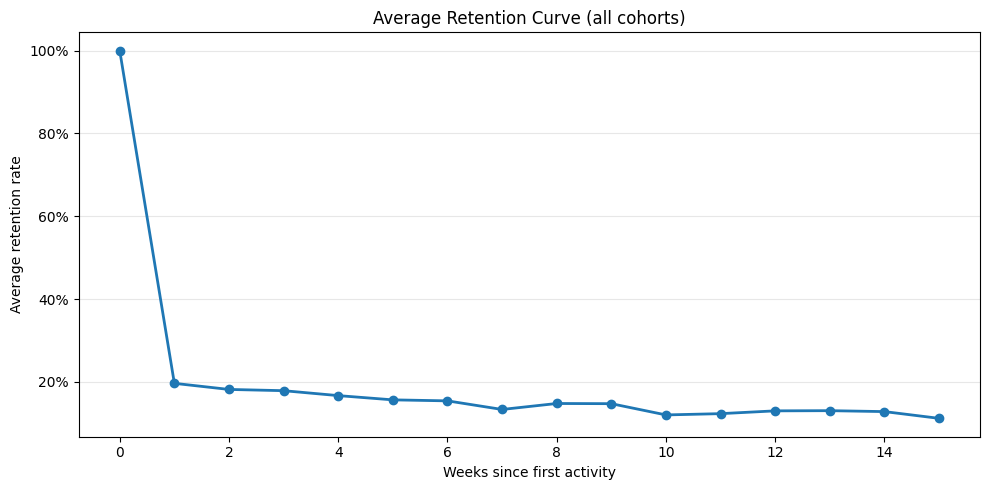

In [11]:
# Average retention curve across all cohorts
avg_retention = matrix.mean(axis=0).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_retention.index, avg_retention.values, marker='o', linewidth=2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('Weeks since first activity')
ax.set_ylabel('Average retention rate')
ax.set_title('Average Retention Curve (all cohorts)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()